<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# 📊 Visualización (continuación)
### Taller de Programación

---

| Sección | Contenido | Librería |
|---|---|---|
| **1. Estadísticos avanzados** | regplot, KDE, ECDF, QQ-plot, FacetGrid | Matplotlib / Seaborn |
| **2. Geoespaciales** | Mapa base, choropleth, burbujas | GeoPandas + Matplotlib |
| **3. Animaciones** | Línea dinámica, bar chart race | Matplotlib FuncAnimation |

```bash
pip install geopandas geodatasets
```

---
## 0. Setup y datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.animation as animation
import seaborn as sns
import geopandas as gpd
import geodatasets
from scipy import stats
from IPython.display import HTML

plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='tab10')

np.random.seed(42)

c:\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


In [2]:
# ── Dataset 1: ventas mensuales por región y producto ─────────────
MESES     = ['Ene','Feb','Mar','Abr','May','Jun',
              'Jul','Ago','Sep','Oct','Nov','Dic']
REGIONES  = ['Norte', 'Centro', 'Sur']
PRODUCTOS = ['Laptop', 'Monitor', 'Teclado', 'Mouse']
PRECIO    = {'Laptop': 1200, 'Monitor': 400, 'Teclado': 80, 'Mouse': 35}

filas = []
for mes_idx, mes in enumerate(MESES):
    for region in REGIONES:
        for producto in PRODUCTOS:
            base          = {'Laptop': 30, 'Monitor': 50, 'Teclado': 120, 'Mouse': 200}[producto]
            tendencia     = 1 + mes_idx * 0.03
            estacional    = 1 + 0.25 * np.sin(2 * np.pi * mes_idx / 12 - np.pi / 2)
            region_factor = {'Norte': 1.2, 'Centro': 1.0, 'Sur': 0.8}[region]
            cantidad      = int(base * tendencia * estacional * region_factor
                                * np.random.uniform(0.85, 1.15))
            filas.append({
                'Mes'     : mes,
                'MesNum'  : mes_idx + 1,
                'Region'  : region,
                'Producto': producto,
                'Cantidad': cantidad,
                'Precio'  : PRECIO[producto],
                'Ingresos' : cantidad * PRECIO[producto],
            })

df_ventas = pd.DataFrame(filas)
print(f"df_ventas: {len(df_ventas)} filas")

df_ventas: 144 filas


In [3]:
# ── Dataset 2: performance de 300 vendedores ──────────────────────
#
# Variables:
#   Experiencia   : años en el puesto (0.5 - 20). Distribución exponencial:
#                   muchos vendedores junior, pocos muy experimentados.
#   Region        : Norte / Centro / Sur. Afecta llamadas y ingresos.
#   Producto      : producto principal que vende. Determina la escala del ticket.
#   LlamadasDia   : llamadas por día. Normal con media distinta por región
#                   (Norte=22, Centro=18, Sur=15).
#   TasaCierre    : proporción de llamadas que terminan en venta cerrada.
#                   Aumenta con la experiencia. Un vendedor nuevo ~8%, uno
#                   experimentado ~20%.
#   CierresMes    : ventas cerradas en el mes = LlamadasDia × 22 días × TasaCierre
#   IngresosMes    : ingresos del mes = CierresMes × ticket promedio × factor experiencia.
#                   El ticket depende del producto (Laptop >> Mouse).
#   Satisfaccion  : satisfacción del cliente (1-10). Levemente correlacionada
#                   con experiencia. Distribución aproximadamente normal.
#                   Se usa en el QQ-plot como contraste con Ingresos (asimétrico).

N = 300

experiencia  = np.random.exponential(scale=5, size=N).clip(0.5, 20).round(1)
region       = np.random.choice(REGIONES, size=N, p=[0.4, 0.35, 0.25])
producto     = np.random.choice(PRODUCTOS, size=N)

region_calls = {'Norte': 22, 'Centro': 18, 'Sur': 15}
llamadas_dia = np.array([
    np.random.normal(region_calls[r], 4) for r in region
]).clip(5, 40).round(0)

tasa_cierre  = (0.08 + experiencia * 0.012 + np.random.normal(0, 0.04, N)).clip(0.03, 0.40)
cierres_mes  = (llamadas_dia * 22 * tasa_cierre).round(0).astype(int)

precio_prod  = np.array([PRECIO[p] for p in producto])
ticket_base  = precio_prod * np.random.uniform(1.5, 4.0, N)
ingresos_mes  = (cierres_mes * ticket_base * (1 + experiencia * 0.03)).round(0)

satisfaccion = (6.5 + experiencia * 0.12 + np.random.normal(0, 1.2, N)).clip(1, 10).round(1)

df_equipo = pd.DataFrame({
    'Experiencia' : experiencia,
    'Region'      : region,
    'Producto'    : producto,
    'LlamadasDia' : llamadas_dia,
    'TasaCierre'  : tasa_cierre.round(3),
    'CierresMes'  : cierres_mes,
    'IngresosMes'  : ingresos_mes,
    'Satisfaccion': satisfaccion,
})

print(f"df_equipo: {len(df_equipo)} filas")
df_equipo.describe().round(2)


df_equipo: 300 filas


,Experiencia,LlamadasDia,TasaCierre,CierresMes,IngresosMes,Satisfaccion
count,300.00,300.00,300.00,300.00,300.00,300.00
mean,4.90,19.27,0.14,60.61,78698.85,7.10
std,4.45,4.62,0.07,31.92,116770.69,1.31
min,0.50,7.00,0.03,10.00,985.00,3.30
25%,1.40,16.00,0.10,38.00,8464.75,6.20
50%,3.75,19.00,0.13,53.00,27614.00,7.10
75%,6.90,22.25,0.18,79.00,108453.00,8.00
max,20.00,32.00,0.40,173.00,794717.00,10.00


In [4]:
# ── Dataset 3: ingresos por país (para el mapa) ────────────────────
paises_data = [
    ('Argentina',                 -38,  -63,  85000,  340),
    ('Brazil',                    -10,  -55, 210000, 1100),
    ('Colombia',                    4,  -74,  62000,  280),
    ('Chile',                     -30,  -71,  74000,  310),
    ('Mexico',                     24, -102, 130000,  590),
    ('United States of America',   38,  -97, 520000, 2400),
    ('Canada',                     60,  -96, 195000,  820),
    ('Germany',                    51,   10, 310000, 1350),
    ('France',                     46,    2, 275000, 1180),
    ('Spain',                      40,   -4, 180000,  760),
    ('Italy',                      42,   12, 165000,  690),
    ('United Kingdom',             54,   -2, 290000, 1250),
    ('Japan',                      36,  138, 340000, 1420),
    ('China',                      35,  105, 480000, 2100),
    ('Australia',                 -25,  133, 220000,  950),
    ('South Africa',              -29,   25,  95000,  390),
    ('India',                      20,   77, 145000,  680),
    ('Russia',                     60,   90, 110000,  430),
]

df_paises = pd.DataFrame(paises_data,
    columns=['name', 'lat', 'lon', 'ingresos', 'clientes'])
df_paises['ingresos']  += np.random.randint(-15000, 15000, len(df_paises))
df_paises['clientes'] += np.random.randint(-50, 50, len(df_paises))

print(f"df_paises: {len(df_paises)} países")

df_paises: 18 países


---
# SECCIÓN 1 — Gráficos estadísticos avanzados

## 1.1 — regplot: relación entre variables

`sns.regplot` ajusta y grafica una regresión lineal con banda de confianza (ci=95% por defecto).
La banda muestra la incertidumbre de la estimación: cuanto más angosta, más confiable.

**Dato:** experiencia del vendedor vs ingresos mensual.

#### Regresión simple

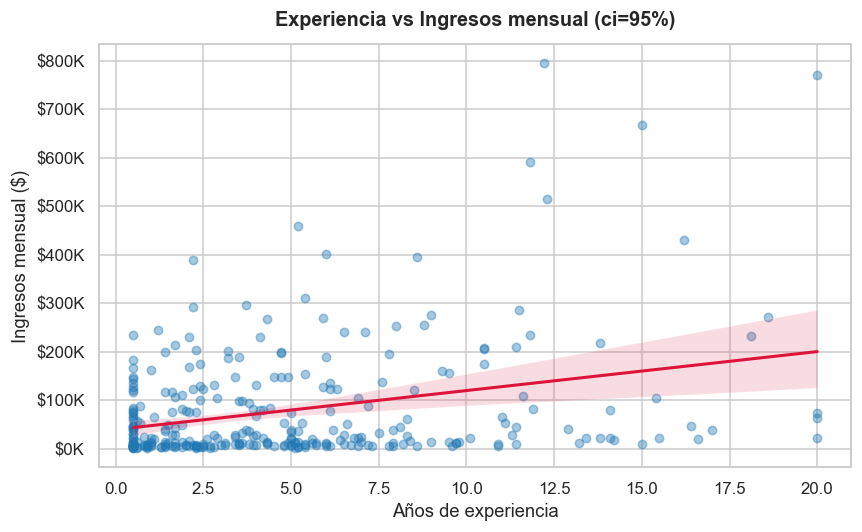

In [5]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df_equipo, x='Experiencia', y='IngresosMes',
            scatter_kws={'alpha': 0.4, 's': 30},
            line_kws={'color': 'crimson', 'linewidth': 2},
            ci=95)

plt.title('Experiencia vs Ingresos mensual (ci=95%)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Años de experiencia')
plt.ylabel('Ingresos mensual ($)')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

#### Regresión por región

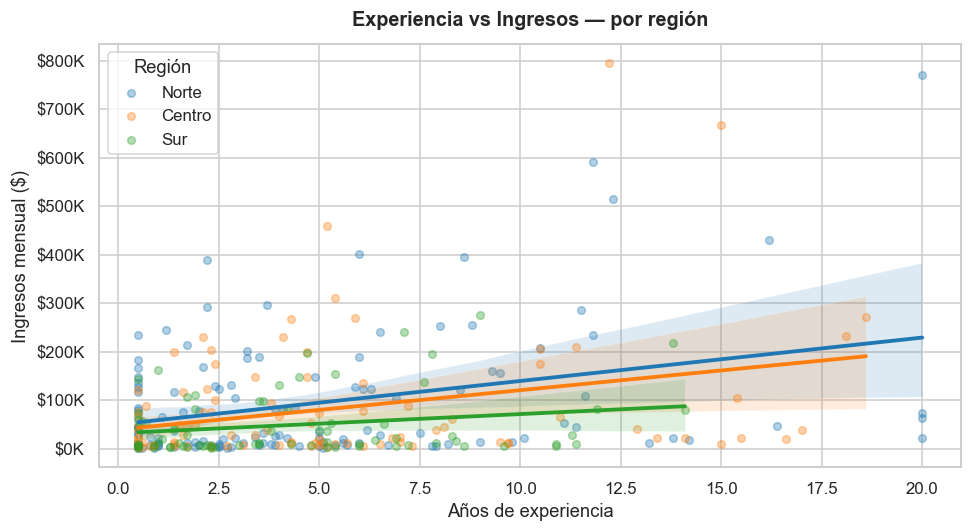

In [6]:
plt.figure(figsize=(9, 5))
for region in REGIONES:
    datos = df_equipo[df_equipo['Region'] == region]
    sns.regplot(data=datos, x='Experiencia', y='IngresosMes',
                scatter_kws={'alpha': 0.35, 's': 25},
                line_kws={'linewidth': 2.5},
                label=region, ci=95)

plt.title('Experiencia vs Ingresos — por región',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Años de experiencia')
plt.ylabel('Ingresos mensual ($)')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()

#### Llamadas por día vs deals cerrados

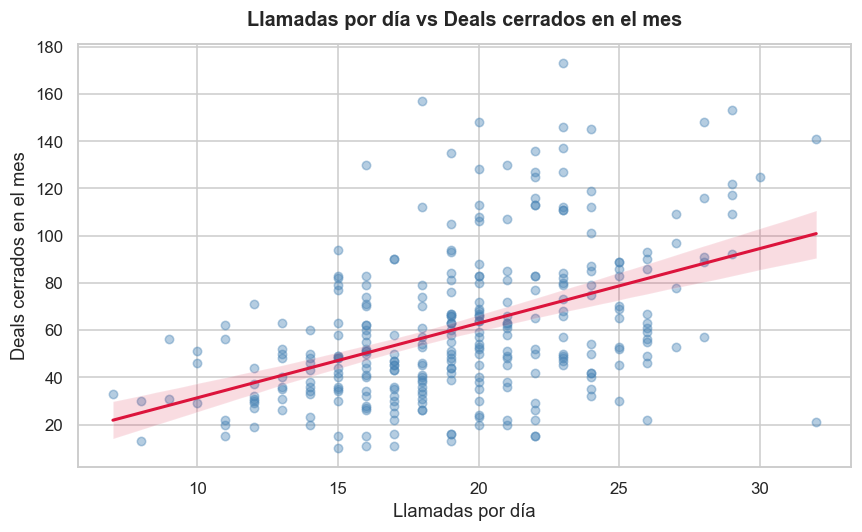

In [7]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df_equipo, x='LlamadasDia', y='CierresMes',
            scatter_kws={'alpha': 0.4, 's': 30, 'color': 'steelblue'},
            line_kws={'color': 'crimson', 'linewidth': 2},
            ci=95)

plt.title('Llamadas por día vs Deals cerrados en el mes',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Llamadas por día')
plt.ylabel('Deals cerrados en el mes')
plt.tight_layout()
plt.show()

## 1.2 — Distribuciones comparadas

**Dato:** distribución del ingresos mensual por región.

#### KDE con área rellena + rug plot

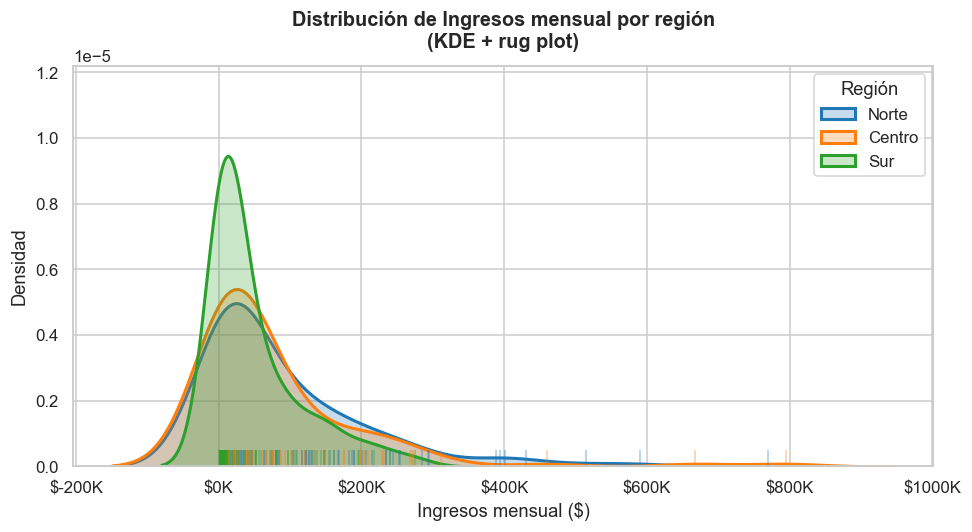

In [8]:
plt.figure(figsize=(9, 5))
for region in REGIONES:
    datos = df_equipo[df_equipo['Region'] == region]['IngresosMes']
    sns.kdeplot(datos, label=region, fill=True, alpha=0.25, linewidth=2)
    sns.rugplot(datos, height=0.04, alpha=0.4)

plt.title('Distribución de Ingresos mensual por región\n(KDE + rug plot)',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Ingresos mensual ($)')
plt.ylabel('Densidad')
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()

#### ECDF — Función de distribución acumulada empírica

Para cada valor x, el ECDF muestra qué proporción de vendedores tiene un ingresos menor o igual a x.
Permite comparar distribuciones sin asumir ninguna forma paramétrica.

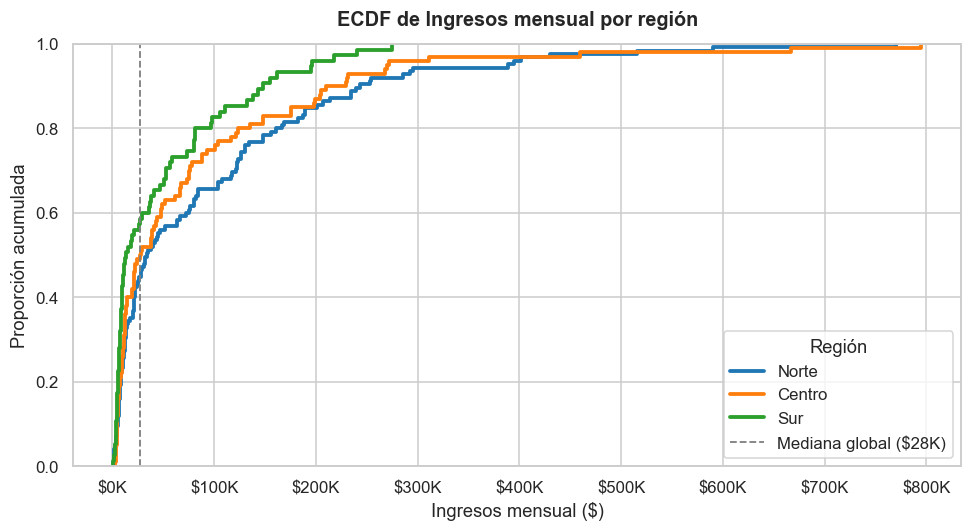

In [9]:
plt.figure(figsize=(9, 5))
for region in REGIONES:
    datos = df_equipo[df_equipo['Region'] == region]['IngresosMes']
    sns.ecdfplot(datos, label=region, linewidth=2.5)

# Línea de referencia: mediana global
mediana = df_equipo['IngresosMes'].median()
plt.axvline(mediana, color='gray', linewidth=1.2, linestyle='--',
            label=f'Mediana global (${mediana/1000:.0f}K)')

plt.title('ECDF de Ingresos mensual por región',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Ingresos mensual ($)')
plt.ylabel('Proporción acumulada')
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()

## 1.3 — QQ-Plot

Compara la distribución de los datos contra una distribución teórica (normal).
- Puntos sobre la diagonal → distribución normal
- Desvíos en los extremos → colas asimétricas o más pesadas que la normal

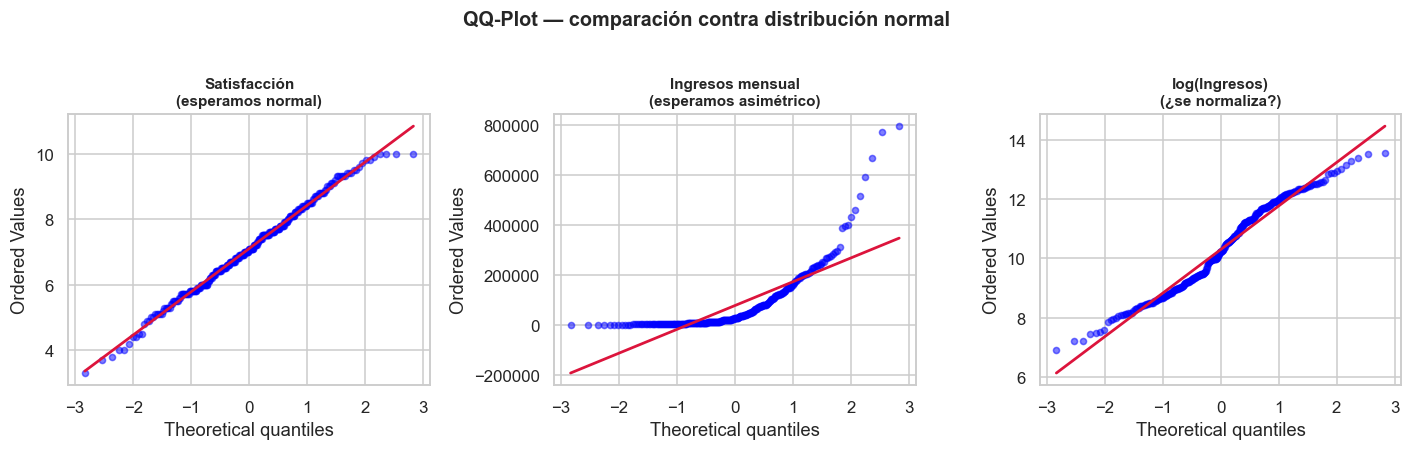

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

datasets_qq = [
    (df_equipo['Satisfaccion'],          'Satisfacción\n(esperamos normal)'),
    (df_equipo['IngresosMes'],            'Ingresos mensual\n(esperamos asimétrico)'),
    (df_equipo['IngresosMes'].apply(np.log), 'log(Ingresos)\n(¿se normaliza?)'),
]

for ax, (datos, titulo) in zip(axes, datasets_qq):
    stats.probplot(datos, dist='norm', plot=ax)
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.get_lines()[0].set(markersize=4, alpha=0.5)
    ax.get_lines()[1].set(color='crimson', linewidth=1.8)

plt.suptitle('QQ-Plot — comparación contra distribución normal',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1.4 — Grilla

Genera automáticamente una grilla de subplots: uno por cada valor único de una variable categórica.

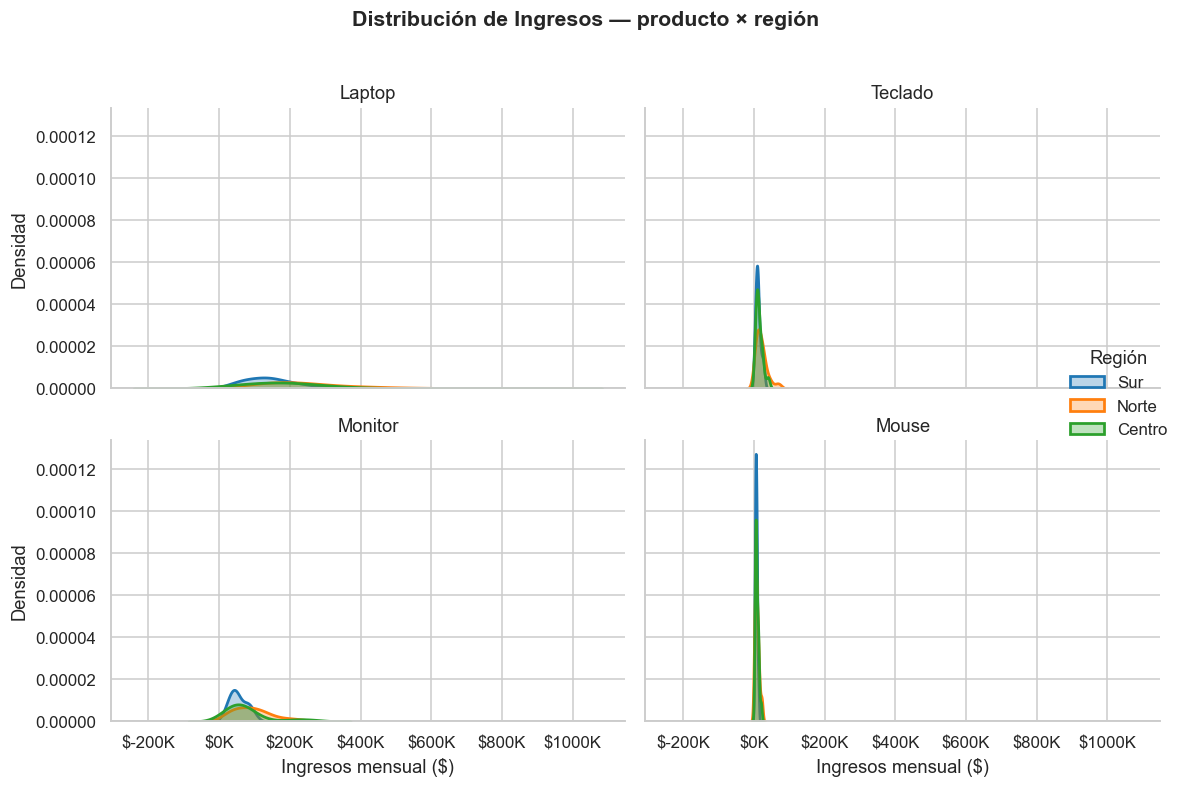

In [11]:
# Distribución de ingresos por producto (un subplot por producto)
g = sns.FacetGrid(df_equipo, col='Producto', col_wrap=2,
                  hue='Region', height=3.5, aspect=1.4)

g.map_dataframe(sns.kdeplot, x='IngresosMes',
                fill=True, alpha=0.3, linewidth=1.8)

g.add_legend(title='Región')
g.set_axis_labels('Ingresos mensual ($)', 'Densidad')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Distribución de Ingresos — producto × región',
                   fontsize=14, fontweight='bold', y=1.02)

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

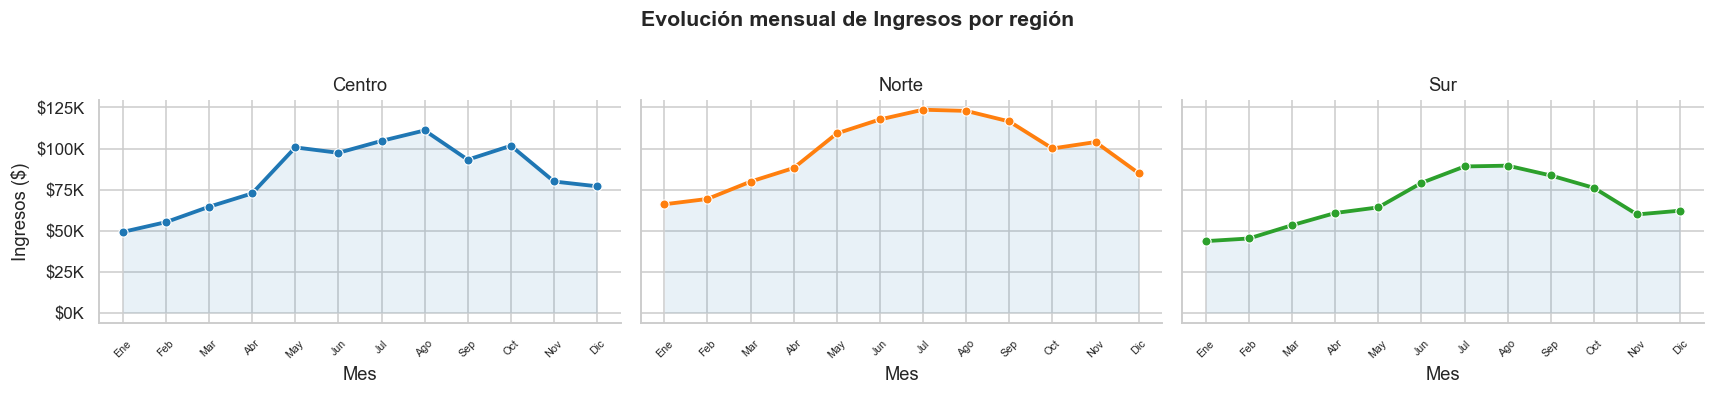

In [12]:
# Evolución mensual de ventas: un subplot por región
ing_mes_region = (
    df_ventas.groupby(['MesNum', 'Mes', 'Region'])['Ingresos']
    .sum().reset_index()
)

g = sns.FacetGrid(ing_mes_region, col='Region',
                  hue='Region', height=3.5, aspect=1.5)

g.map_dataframe(sns.lineplot, x='MesNum', y='Ingresos',
                marker='o', linewidth=2.5)

g.set_axis_labels('Mes', 'Ingresos ($)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Evolución mensual de Ingresos por región',
                   fontsize=14, fontweight='bold', y=1.02)

for ax in g.axes.flat:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MESES, rotation=45, fontsize=7)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.fill_between(
        ing_mes_region[ing_mes_region['Region'] == ax.get_title()]['MesNum'],
        ing_mes_region[ing_mes_region['Region'] == ax.get_title()]['Ingresos'],
        alpha=0.1
    )

plt.tight_layout()
plt.show()

---
# SECCIÓN 2 — Gráficos Geoespaciales

## 2.1 — Mapa base

In [29]:
try:
    mundo = gpd.read_file(geodatasets.get_path('naturalearth_lowres'))
    print("✅ Cargado con geodatasets")
except Exception:
    URL_MAP = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    mundo = gpd.read_file(URL_MAP)
    mundo = mundo.rename(columns={'NAME': 'name', 'CONTINENT': 'continent', 'POP_EST': 'pop_est'})

print(f"Columnas: {mundo.columns.tolist()}")

Columnas: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'name', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'pop_est', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_A

<Figure size 2200x880 with 0 Axes>

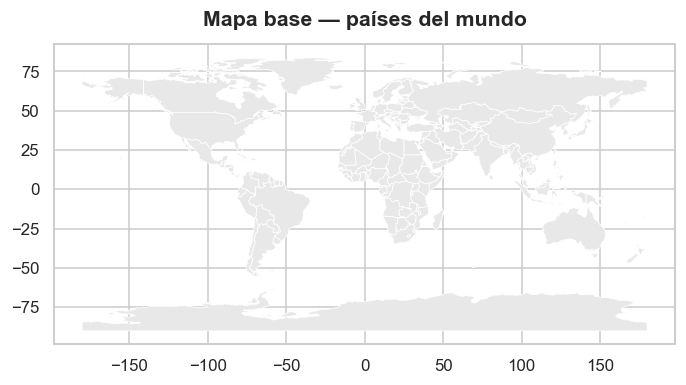

In [30]:
plt.figure(figsize=(20, 8))
mundo.plot(color='#e8e8e8', edgecolor='white', linewidth=0.5)

plt.title('Mapa base — países del mundo',  fontsize=14, fontweight='bold', pad=12)
#plt.axis('off')
plt.tight_layout()
plt.show()

<Figure size 2200x880 with 0 Axes>

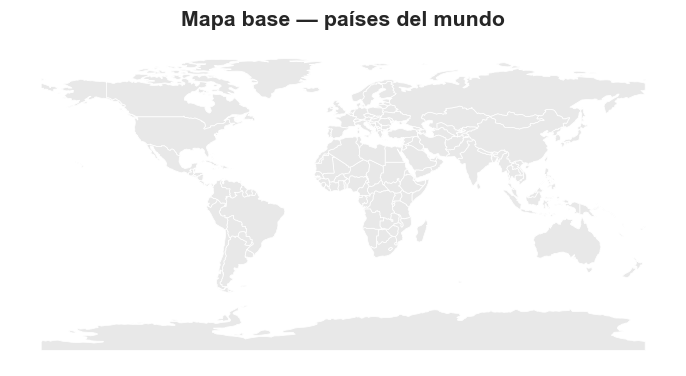

In [31]:
plt.figure(figsize=(20, 8))
mundo.plot(color='#e8e8e8', edgecolor='white', linewidth=0.5)

plt.title('Mapa base — países del mundo',  fontsize=14, fontweight='bold', pad=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## 2.2 — Ingresos por país

In [32]:
mundo_rev = mundo.merge(df_paises[['name', 'ingresos', 'clientes']], on='name', how='left')

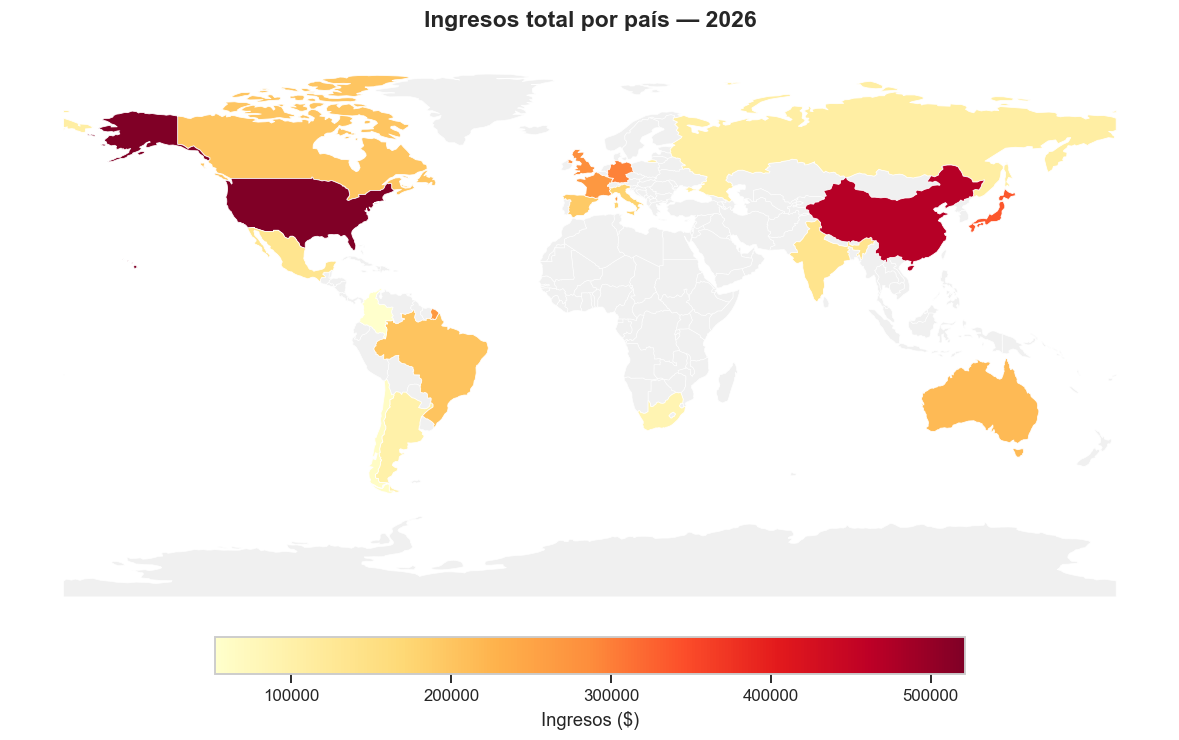

In [33]:
fig, ax = plt.subplots(figsize=(14, 7))

# Países sin datos
mundo_rev[mundo_rev['ingresos'].isna()].plot(
    ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.4
)

# Choropleth
mundo_rev[ mundo_rev['ingresos'].notna() ].plot(
    ax=ax,
    column='ingresos',
    cmap='YlOrRd',
    edgecolor='white',
    linewidth=0.5,
    legend=True,
    legend_kwds={
        'label'      : 'Ingresos ($)',
        'orientation': 'horizontal',
        'shrink'     : 0.5,
        'pad'        : 0.02,
    }
)

ax.set_title('Ingresos total por país — 2026',
             fontsize=15, fontweight='bold', pad=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## 2.3 — Mapa de burbujas

Tamaño del punto = ingresos. Color = número de clientes.

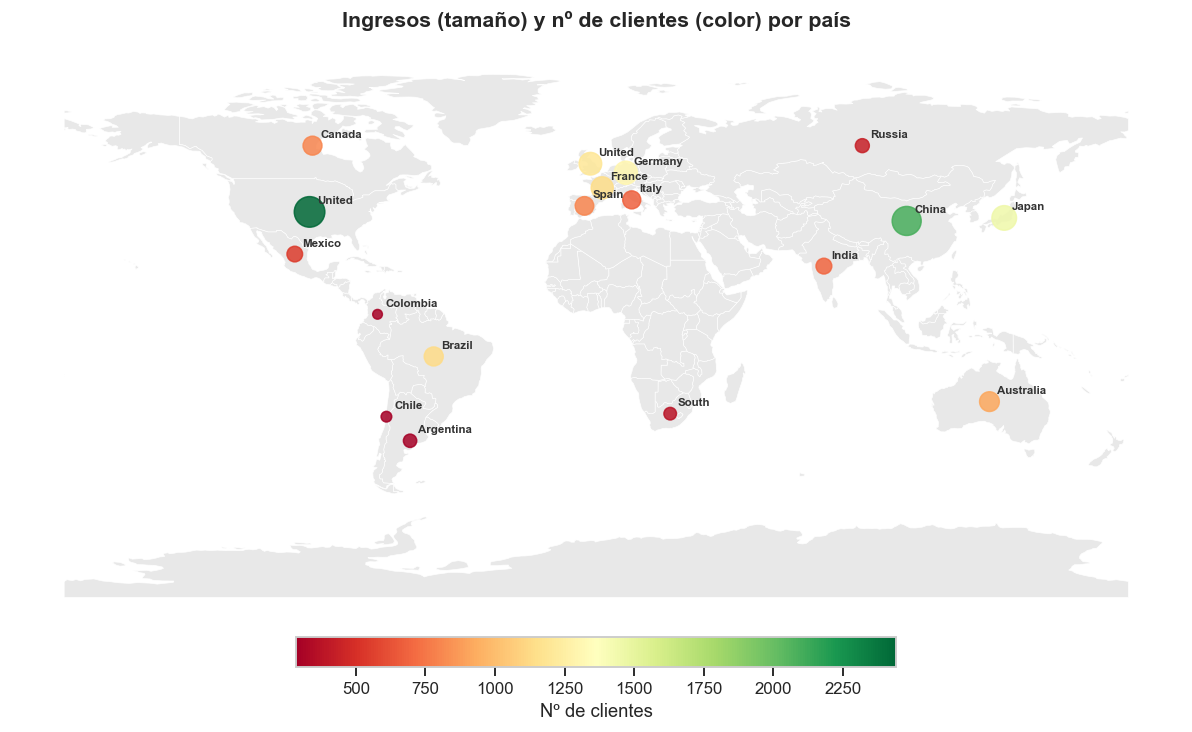

In [34]:
gdf_puntos = gpd.GeoDataFrame(  df_paises,  geometry=gpd.points_from_xy(df_paises['lon'], df_paises['lat']),  crs='EPSG:4326')

fig, ax = plt.subplots(figsize=(14, 7))

mundo.plot(ax=ax, color='#e8e8e8', edgecolor='white', linewidth=0.4)

gdf_puntos.plot(
    ax=ax,
    column='clientes',
    cmap='RdYlGn',
    markersize=gdf_puntos['ingresos'] / gdf_puntos['ingresos'].max() * 400,
    alpha=0.85,
    legend=True,
    legend_kwds={
        'label'      : 'Nº de clientes',
        'orientation': 'horizontal',
        'shrink'     : 0.4,
        'pad'        : 0.02,
    }
)

for _, row in gdf_puntos.iterrows():
    ax.annotate(
        row['name'].split(' ')[0],
        xy=(row['lon'], row['lat']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=7.5, color='#333333', fontweight='bold'
    )

ax.set_title('Ingresos (tamaño) y nº de clientes (color) por país',
             fontsize=14, fontweight='bold', pad=14)
ax.axis('off')
plt.tight_layout()
plt.show()

---
# SECCIÓN 3 — Animaciones con FuncAnimation

```python
fig, ax = plt.subplots()

def actualizar(frame):
    ax.clear()
    # dibujar el frame número 'frame'

ani = FuncAnimation(fig, actualizar, frames=N, interval=ms_entre_frames)
HTML(ani.to_jshtml())   # mostrar en la notebook
```

## 3.1 — Línea que crece mes a mes

In [35]:
ing_mensual = (
    df_ventas.groupby('MesNum')['Ingresos']
    .sum().reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

def actualizar_linea(frame):
    ax.clear()
    datos = ing_mensual.iloc[:frame + 1]

    ax.plot(datos['MesNum'], datos['Ingresos'],
            color='steelblue', linewidth=2.5, marker='o', markersize=6)
    ax.fill_between(datos['MesNum'], datos['Ingresos'],
                    alpha=0.15, color='steelblue')
    ax.scatter(datos['MesNum'].iloc[-1], datos['Ingresos'].iloc[-1],
               color='crimson', zorder=5, s=90)

    ax.set_xlim(0.5, 12.5)
    ax.set_ylim(0, ing_mensual['Ingresos'].max() * 1.15)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MESES)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.set_title(f'Ingresos mensual — {MESES[frame]}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Ingresos ($)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ani_linea = animation.FuncAnimation(
    fig, actualizar_linea,
    frames=len(ing_mensual),
    interval=400,
    repeat=True
)

plt.close()
HTML(ani_linea.to_jshtml())

## 3.2 — Bar chart race: ingresos acumulado por región

In [36]:
ing_acum = (
    df_ventas.groupby(['MesNum', 'Region'])['Ingresos']
    .sum()
    .groupby(level='Region')
    .cumsum()
    .reset_index()
)

COLORES_REG = dict(zip(REGIONES, sns.color_palette('tab10', len(REGIONES))))

fig, ax = plt.subplots(figsize=(8, 4))

def actualizar_barras(frame):
    ax.clear()
    mes = frame + 1

    datos = (
        ing_acum[ing_acum['MesNum'] == mes]
        .sort_values('Ingresos', ascending=True)
    )

    colores = [COLORES_REG[r] for r in datos['Region']]
    bars = ax.barh(datos['Region'], datos['Ingresos'],
                   color=colores, edgecolor='white', height=0.5)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 3000, bar.get_y() + bar.get_height() / 2,
                f'${w/1000:.0f}K', va='center', fontsize=11, fontweight='bold')

    ax.set_xlim(0, ing_acum['Ingresos'].max() * 1.2)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.set_title(f'Ingresos acumulado por región — hasta {MESES[frame]}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Ingresos acumulado ($)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ani_barras = animation.FuncAnimation(
    fig, actualizar_barras,
    frames=12,
    interval=500,
    repeat=True
)

plt.close()
HTML(ani_barras.to_jshtml())

## 3.3 — Exportar como GIF

```bash
pip install pillow
```

In [ ]:
# Descomentá para exportar

# ani_linea.save('ingresos_mensual.gif', writer='pillow', fps=2)
# print('✅ Guardado: ingresos_mensual.gif')

# ani_barras.save('bar_chart_race.gif', writer='pillow', fps=1)
# print('✅ Guardado: bar_chart_race.gif')